# SRP v4 — Step 4b: The Grinsztajn Diagnostics

Grinsztajn, Oyallon & Varoquaux (2022), *"Why do tree-based models still outperform deep learning on typical
tabular data?"*, identified three properties that let trees beat neural networks. They showed each one with a
**perturbation test**: change the data in one specific way and watch which models get hurt.

| Property trees have | Test | What a tree does | What an MLP does |
|---|---|---|---|
| **Robust to uninformative features** | Append columns of pure noise | Barely moves | Gets worse |
| **Uses the feature axes** (not rotation-invariant) | Randomly rotate all features | **Gets worse** (its splits lose meaning) | Doesn't move at all |
| **Learns irregular, jumpy functions** | Smooth the training labels | Gets worse (it was exploiting sharp structure) | Barely moves (it couldn't learn it anyway) |

**The question for this project:** where do *our* models sit between those two extremes? For each property, we
compute a **tree-likeness score**: **0** means our model reacts like the MLP, **1** means it reacts like XGBoost.
A low score marks a property our architecture lacks, which is where a Grinsztajn-inspired fix
(feature gates, per-feature embeddings, soft-tree experts) could help.

### Setup

| | |
|---|---|
| **Datasets** | Covertype (7 classes, 54 features), Poker Hand (10 features; 8 classes appear in the sample), HIGGS (binary, 28 features) |
| **Sample size** | 10,000 train / 5,000 val / 20,000 test per dataset, drawn once and shared by every model and condition. This is the paper's own "medium-sized" regime. |
| **Models** | XGBoost (tree anchor) · PlainMLP (MLP anchor) · **Mean-pool (wide head)** · **Causal attn** |
| **Conditions** | baseline · noise +50% · noise +100% · rotation · smoothing light (~10% of labels changed) · smoothing strong (~25%) |
| **Seeds** | 3 per model per condition |
| **Metric** | test accuracy, reported as the **change from each model's own baseline** (paired by seed) |

**Hyperparameters are fixed across conditions:** each model is tuned (or configured) once and then reacts to the
perturbations with no retuning. XGBoost is tuned per dataset on the baseline condition (25 Optuna trials). Our
models use the step-3 configuration, designed on California Housing. That makes XGBoost's *absolute* numbers
somewhat favoured, but the diagnostics are about *changes*, which that asymmetry affects much less.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd()
sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from joblib import Parallel, delayed

from datasets import make_task
from diagnostics import add_noise_features, rotate_features, smooth_to_fraction
from tuning import tune_xgb

DATASETS_USED   = ("covertype", "poker", "higgs")
N_TRAIN, N_VAL, N_TEST = 10_000, 5_000, 20_000
SEEDS           = (0, 1, 2)
XGB_TRIALS      = 25
THREADS_PER_JOB = 2
N_JOBS          = max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB))

ENS_KW   = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, dropout=0.1, feature_frac=0.7)
ATT_KW   = dict(embed_dim=32, num_heads=4, attn_depth=2, ff_mult=4, dropout=0.1, need_weights=False)
TRAIN_KW = dict(epochs=200, lr=1e-3, batch_size=256, weight_decay=1e-4, patience=20)

MODELS = ["XGBoost", "PlainMLP", "meanpool_wide", "causal"]
OURS   = ["meanpool_wide", "causal"]
LABEL  = {"XGBoost": "XGBoost", "PlainMLP": "PlainMLP",
          "meanpool_wide": "Mean-pool (wide head)", "causal": "Causal attn"}
COLOR  = {"XGBoost": "#ff8a3d", "PlainMLP": "#4c8dff", "meanpool_wide": "#7b5cff", "causal": "#e0527a"}
COND_LABEL = {"baseline": "baseline", "noise50": "noise +50%", "noise100": "noise +100%",
              "rotation": "rotation", "smooth_light": "smoothing ~10%", "smooth_strong": "smoothing ~25%"}
DS_LABEL = {"covertype": "Covertype", "poker": "Poker Hand", "higgs": "HIGGS"}

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
LOG_PATH = os.path.join(RUN_DIR, "04_progress.log")
if os.path.exists(LOG_PATH): os.remove(LOG_PATH)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")

def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

sns.set_theme(style="whitegrid", context="notebook")
log(f"{N_JOBS} workers x {THREADS_PER_JOB} threads | datasets {DATASETS_USED}")

8 workers x 2 threads | datasets ('covertype', 'poker', 'higgs')


## 1. Load the datasets and build every condition

Each dataset is sampled once. The five perturbed versions are built from that same sample, so the only
thing that differs between conditions is the perturbation itself.

In [2]:
TASKS, SMOOTH_INFO = {}, {}
for ds in DATASETS_USED:
    t0 = time.time()
    base = make_task(ds, n_train=N_TRAIN, n_val=N_VAL, n_test=N_TEST, seed=0)
    light, info_l = smooth_to_fraction(base, 0.10)
    strong, info_s = smooth_to_fraction(base, 0.25)
    TASKS[ds] = {"baseline": base,
                 "noise50":  add_noise_features(base, 0.5, seed=1),
                 "noise100": add_noise_features(base, 1.0, seed=1),
                 "rotation": rotate_features(base, seed=1),
                 "smooth_light": light, "smooth_strong": strong}
    SMOOTH_INFO[ds] = {"light": info_l, "strong": info_s}
    log(f"{base.summary()}  ({time.time()-t0:.0f}s)")

rows = []
for ds in DATASETS_USED:
    for cond, t in TASKS[ds].items():
        extra = ""
        if cond.startswith("smooth"):
            i = SMOOTH_INFO[ds]["light" if cond == "smooth_light" else "strong"]
            extra = f"{i['labels_changed']:.1%} of train labels changed (bandwidth x{i['bandwidth_mult']:.2f})"
        elif cond.startswith("noise"):
            extra = f"+{t.info['noise_features']} pure-noise columns"
        elif cond == "rotation":
            extra = "all features rotated by one random orthogonal matrix"
        rows.append({"dataset": DS_LABEL[ds], "condition": COND_LABEL[cond], "features": t.n_features,
                     "classes": t.n_classes, "majority acc": t.majority_acc, "what changed": extra})
show(pd.DataFrame(rows).set_index(["dataset", "condition"]), {"majority acc": "{:.3f}"})

covertype   multiclass features= 54 train=10,000 val=5,000 test=20,000  classes=7  majority-class acc=0.490  (11s)


poker       multiclass features= 10 train=10,000 val=5,000 test=20,000  classes=8  majority-class acc=0.505  (6s)


higgs       binary     features= 28 train=10,000 val=5,000 test=20,000  classes=2  majority-class acc=0.530  (9s)


features  classes  majority acc  \
dataset    condition                                         
Covertype  baseline              54        7        0.4898   
           noise +50%            81        7        0.4898   
           noise +100%          108        7        0.4898   
           rotation              54        7        0.4898   
           smoothing ~10%        54        7        0.4898   
           smoothing ~25%        54        7        0.4898   
Poker Hand baseline              10        8        0.5053   
           noise +50%            15        8        0.5053   
           noise +100%           20        8        0.5053   
           rotation              10        8        0.5053   
           smoothing ~10%        10        8        0.5053   
           smoothing ~25%        10        8        0.5053   
HIGGS      baseline              28        2        0.5303   
           noise +50%            42        2        0.5303   
           noise +100%           56        2        0.5303   
           rotation              28        2        0.5303   
           smoothing ~10%        28        2        0.5303   
           smoothing ~25%        28        2        0.5303   

                                                                what changed  
dataset    condition                                                          
Covertype  baseline                                                           
           noise +50%                                 +27 pure-noise columns  
           noise +100%                                +54 pure-noise columns  
           rotation        all features rotated by one random orthogonal ...  
           smoothing ~10%    10.8% of train labels changed (bandwidth x0.92)  
           smoothing ~25%    24.6% of train labels changed (bandwidth x1.56)  
Poker Hand baseline                                                           
           noise +50%                                  +5 pure-noise columns  
           noise +100%                                +10 pure-noise columns  
           rotation        all features rotated by one random orthogonal ...  
           smoothing ~10%    10.9% of train labels changed (bandwidth x0.74)  
           smoothing ~25%    24.2% of train labels changed (bandwidth x1.34)  
HIGGS      baseline                                                           
           noise +50%                                 +14 pure-noise columns  
           noise +100%                                +28 pure-noise columns  
           rotation        all features rotated by one random orthogonal ...  
           smoothing ~10%     9.3% of train labels changed (bandwidth x0.51)  
           smoothing ~25%    25.5% of train labels changed (bandwidth x0.61)

## 2. Tune XGBoost once per dataset (baseline condition only)

In [3]:
XGB_PARAMS = {}
for ds in DATASETS_USED:
    t0 = time.time()
    base = TASKS[ds]["baseline"]
    st = tune_xgb(base.arrays(), base.task, n_trials=XGB_TRIALS, seed=0)
    XGB_PARAMS[ds] = st.best_params
    log(f"[xgb tune] {DS_LABEL[ds]:10s} best val acc {st.best_value:.4f}  ({(time.time()-t0)/60:.1f} min)")

[xgb tune] Covertype  best val acc 0.8194  (1.7 min)


[xgb tune] Poker Hand best val acc 0.7208  (0.5 min)


[xgb tune] HIGGS      best val acc 0.7248  (0.3 min)


## 3. Train everything

3 datasets × 6 conditions × 4 models × 3 seeds = **216 runs**, spread across the worker pool (slowest first).
This is the long cell.

In [4]:
def run_diag_job(ds, cond, model_name, seed, arrays, task_kind, output_dim, xgb_params,
                 ens_kw, att_kw, train_kw, project_dir, threads):
    import sys, time
    if project_dir not in sys.path:
        sys.path.insert(0, project_dir)
    import numpy as np, torch
    from weak_learners import WeakLearnerConfig
    from attention import AttentionConfig
    from model import make_arm, PlainMLP
    from training import train_model, evaluate
    from tuning import make_xgb, xgb_metrics

    torch.set_num_threads(threads)
    t0 = time.time()
    if model_name == "XGBoost":
        ytr = arrays["ytr"].astype(int)
        m = make_xgb(xgb_params, task_kind, seed=seed, n_jobs=threads).fit(arrays["Xtr"], ytr)
        res = xgb_metrics(m, arrays["Xte"], arrays["yte"], task_kind)
        extra = {"best_epoch": np.nan, "n_params": np.nan}
    else:
        data = {k: torch.as_tensor(v) for k, v in arrays.items()}
        in_dim = data["Xtr"].shape[1]
        torch.manual_seed(seed); np.random.seed(seed)
        if model_name == "PlainMLP":
            model = PlainMLP(in_dim, task=task_kind, output_dim=output_dim)
        else:
            model = make_arm(model_name, in_dim, WeakLearnerConfig(**ens_kw, seed=seed, batched=True),
                             AttentionConfig(**att_kw), task=task_kind, output_dim=output_dim)
        model, hist = train_model(model, data, seed=seed, **train_kw)
        res = evaluate(model, data["Xte"], arrays["yte"], task_kind)
        extra = {"best_epoch": hist["best_epoch"] + 1, "n_params": sum(p.numel() for p in model.parameters())}
    return {"dataset": ds, "condition": cond, "model": model_name, "seed": seed, **res, **extra,
            "seconds": time.time() - t0}

COST = {"causal": 4, "meanpool_wide": 2, "PlainMLP": 1, "XGBoost": 1}
jobs = [(ds, cond, m, s) for ds in DATASETS_USED for cond in TASKS[ds] for m in MODELS for s in SEEDS]
jobs.sort(key=lambda j: -COST[j[2]])
log(f"{len(jobs)} runs on {N_JOBS} workers ...")

t0, RECORDS = time.time(), []
for r in Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(run_diag_job)(ds, cond, m, s, TASKS[ds][cond].arrays(), TASKS[ds][cond].task,
                              TASKS[ds][cond].output_dim, XGB_PARAMS[ds], ENS_KW, ATT_KW, TRAIN_KW,
                              PROJECT_DIR, THREADS_PER_JOB)
        for ds, cond, m, s in jobs):
    RECORDS.append(r)
    if len(RECORDS) % 12 == 0 or len(RECORDS) == len(jobs):
        log(f"  {len(RECORDS):3d}/{len(jobs)} runs done  |  elapsed {(time.time()-t0)/60:.1f} min")
R = pd.DataFrame(RECORDS)
log(f"all runs done in {(time.time()-t0)/60:.1f} min")

216 runs on 8 workers ...


/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not wr

/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


/tmp/ipykernel_79360/306602093.py:21: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


...

  180/216 runs done  |  elapsed 26.6 min


  192/216 runs done  |  elapsed 26.8 min


  204/216 runs done  |  elapsed 26.9 min


  216/216 runs done  |  elapsed 27.0 min


all runs done in 27.0 min


## 4. Baseline: how do the models compare before any perturbation?

Baseline test accuracy (mean over 3 seeds)


,XGBoost,PlainMLP,Mean-pool (wide head),Causal attn,majority class
Covertype,0.8194,0.7913,0.7774,0.7887,0.4898
HIGGS,0.7073,0.6812,0.6872,0.6680,0.5303
Poker Hand,0.6992,0.5676,0.6035,0.5860,0.5053


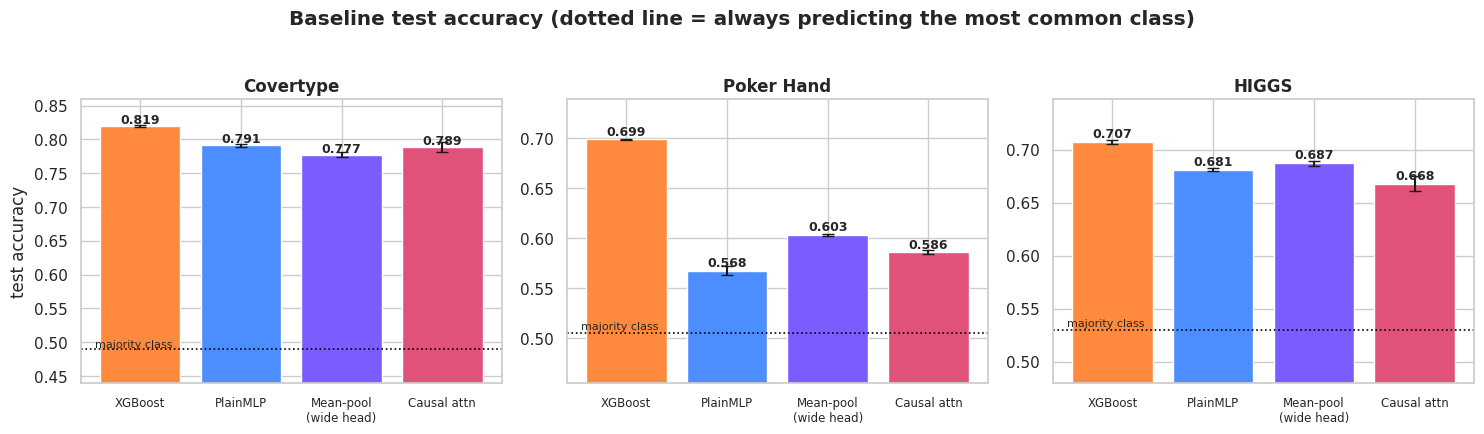

In [5]:
base = R[R.condition == "baseline"]
tab = base.pivot_table(index="dataset", columns="model", values="acc", aggfunc="mean")[MODELS]
sd = base.pivot_table(index="dataset", columns="model", values="acc", aggfunc="std")[MODELS]
out = tab.copy()
out.columns = [LABEL[c] for c in out.columns]
out["majority class"] = [TASKS[ds]["baseline"].majority_acc for ds in tab.index]
out.index = [DS_LABEL[i] for i in out.index]
print("Baseline test accuracy (mean over 3 seeds)")
show(out, {c: "{:.4f}" for c in out.columns},
     style=lambda s: s.highlight_max(axis=1, subset=[LABEL[m] for m in MODELS], color="#e8e0ff"))

fig, axes = plt.subplots(1, len(DATASETS_USED), figsize=(15, 4.2))
for ax, ds in zip(axes, DATASETS_USED):
    vals = [tab.loc[ds, m] for m in MODELS]; errs = [sd.loc[ds, m] for m in MODELS]
    ax.bar(range(len(MODELS)), vals, yerr=errs, capsize=4, color=[COLOR[m] for m in MODELS], edgecolor="white")
    maj = TASKS[ds]["baseline"].majority_acc
    ax.axhline(maj, color="black", ls=":", lw=1.2); ax.text(-0.45, maj + 0.003, "majority class", fontsize=8)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels([LABEL[m].replace(" (", "\n(") for m in MODELS], fontsize=8.5)
    ax.set_ylim(maj - 0.05, max(vals) + 0.04); ax.set_title(DS_LABEL[ds], fontweight="bold")
axes[0].set_ylabel("test accuracy")
plt.suptitle("Baseline test accuracy (dotted line = always predicting the most common class)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

## 5. The diagnostics: how much does each perturbation hurt each model?

Every bar is **accuracy under the perturbation minus accuracy at baseline**, for the same model and seed
(paired). Below zero means the perturbation hurt.

**What to look for:** XGBoost (orange) and PlainMLP (blue) are the two anchors. For each test, ask which
anchor our two models (purple, pink) resemble.

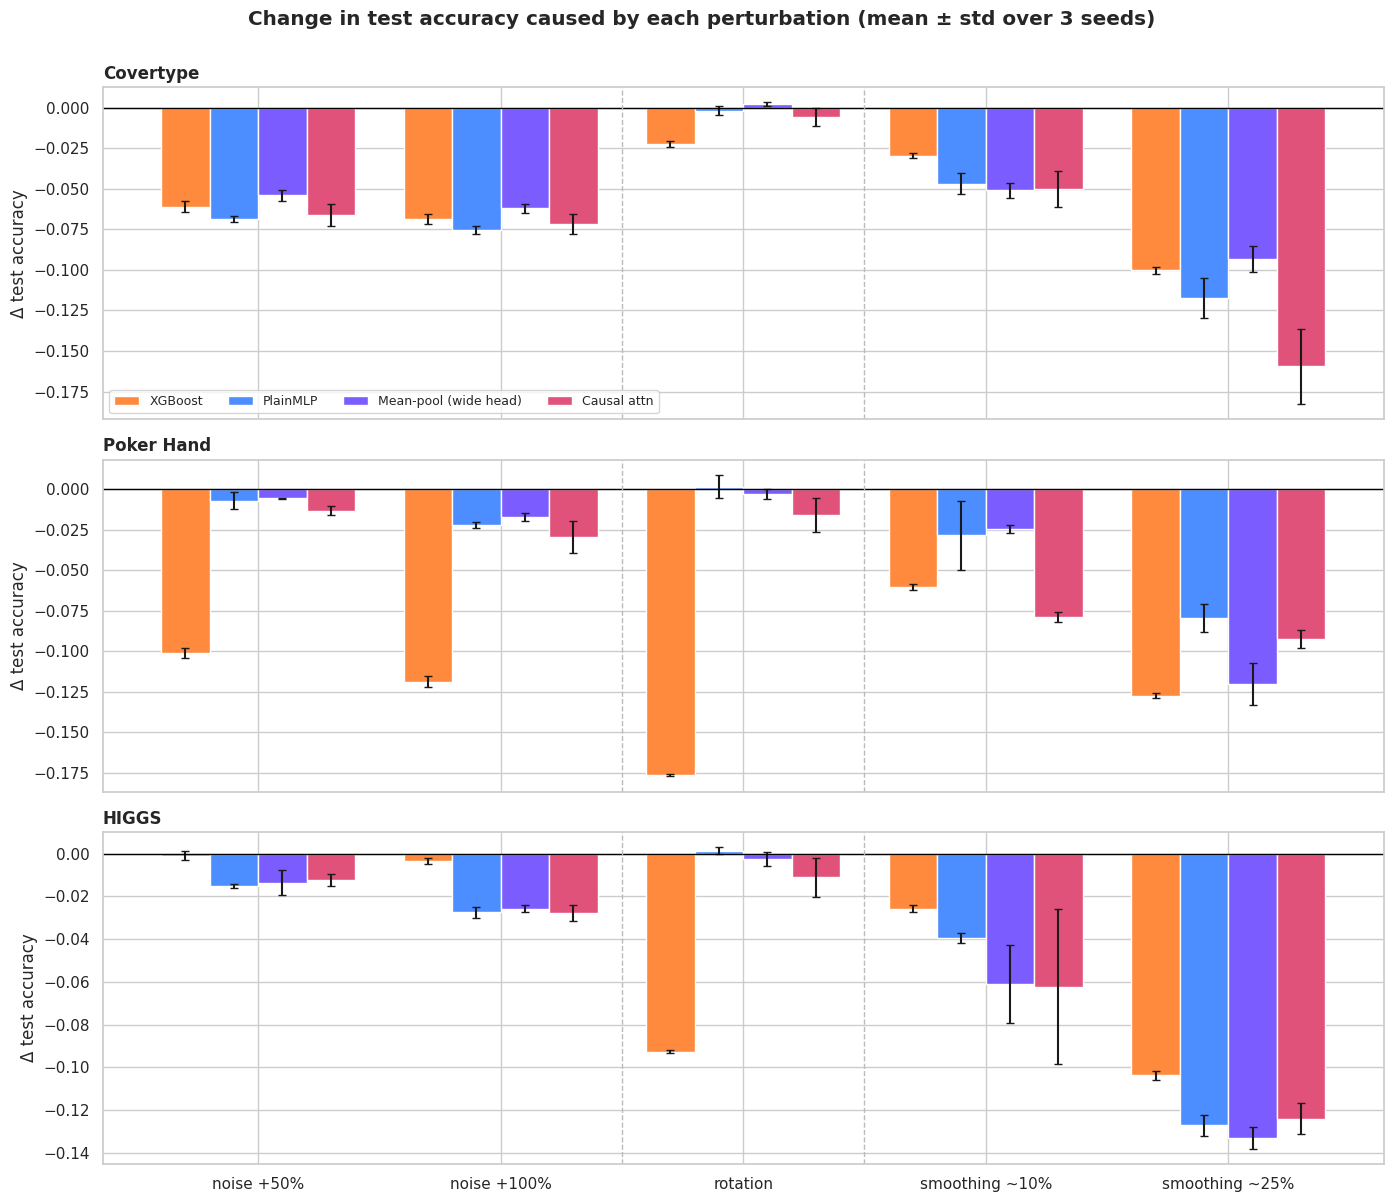

Δ test accuracy vs baseline (mean over seeds; negative = hurt)


XGBoost  PlainMLP  Mean-pool (wide head)  \
Covertype  noise +50%      -0.0612   -0.0687                -0.0539   
           noise +100%     -0.0685   -0.0755                -0.0621   
           rotation        -0.0225   -0.0019                 0.0021   
           smoothing ~10%  -0.0296   -0.0468                -0.0510   
           smoothing ~25%  -0.1002   -0.1173                -0.0935   
Poker Hand noise +50%      -0.1009   -0.0072                -0.0057   
           noise +100%     -0.1186   -0.0219                -0.0174   
           rotation        -0.1763    0.0016                -0.0030   
           smoothing ~10%  -0.0604   -0.0284                -0.0246   
           smoothing ~25%  -0.1274   -0.0793                -0.1201   
HIGGS      noise +50%      -0.0009   -0.0150                -0.0136   
           noise +100%     -0.0034   -0.0275                -0.0257   
           rotation        -0.0926    0.0014                -0.0026   
           smoothing ~10%  -0.0258   -0.0394                -0.0608   
           smoothing ~25%  -0.1038   -0.1271                -0.1329   

                           Causal attn  
Covertype  noise +50%          -0.0662  
           noise +100%         -0.0715  
           rotation            -0.0058  
           smoothing ~10%      -0.0503  
           smoothing ~25%      -0.1596  
Poker Hand noise +50%          -0.0132  
           noise +100%         -0.0295  
           rotation            -0.0160  
           smoothing ~10%      -0.0787  
           smoothing ~25%      -0.0923  
HIGGS      noise +50%          -0.0122  
           noise +100%         -0.0278  
           rotation            -0.0111  
           smoothing ~10%      -0.0622  
           smoothing ~25%      -0.1240

In [6]:
b = R[R.condition == "baseline"].set_index(["dataset", "model", "seed"])["acc"]
D = R[R.condition != "baseline"].copy()
D["delta"] = D.apply(lambda r: r["acc"] - b[(r["dataset"], r["model"], r["seed"])], axis=1)
PERTURB = ["noise50", "noise100", "rotation", "smooth_light", "smooth_strong"]

fig, axes = plt.subplots(len(DATASETS_USED), 1, figsize=(14, 4 * len(DATASETS_USED)), sharex=True)
w = 0.2
for ax, ds in zip(axes, DATASETS_USED):
    for i, m in enumerate(MODELS):
        g = D[(D.dataset == ds) & (D.model == m)].groupby("condition")["delta"].agg(["mean", "std"]).reindex(PERTURB)
        ax.bar(np.arange(len(PERTURB)) + (i - 1.5) * w, g["mean"], w, yerr=g["std"], capsize=3,
               color=COLOR[m], label=LABEL[m], edgecolor="white")
    ax.axhline(0, color="black", lw=1)
    ax.set_ylabel("Δ test accuracy"); ax.set_title(DS_LABEL[ds], fontweight="bold", loc="left")
    ax.axvline(1.5, color="#bbb", lw=1, ls="--"); ax.axvline(2.5, color="#bbb", lw=1, ls="--")
axes[0].legend(ncol=4, fontsize=9, loc="lower left")
axes[-1].set_xticks(range(len(PERTURB))); axes[-1].set_xticklabels([COND_LABEL[c] for c in PERTURB])
plt.suptitle("Change in test accuracy caused by each perturbation (mean ± std over 3 seeds)",
             fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

delta_tab = D.pivot_table(index=["dataset", "condition"], columns="model", values="delta", aggfunc="mean")[MODELS]
delta_tab = delta_tab.reindex(pd.MultiIndex.from_product([DATASETS_USED, PERTURB]))
delta_tab.index = delta_tab.index.map(lambda t: (DS_LABEL[t[0]], COND_LABEL[t[1]]))
delta_tab.columns = [LABEL[c] for c in delta_tab.columns]
print("Δ test accuracy vs baseline (mean over seeds; negative = hurt)")
show(delta_tab, {c: "{:+.4f}" for c in delta_tab.columns},
     style=lambda s: s.background_gradient(cmap="RdBu", vmin=-0.08, vmax=0.08, axis=None))

## 6. Tree-likeness scores: which anchor do our models behave like?

For each test and dataset:

$$\text{tree-likeness} = \frac{\Delta_\text{ours} - \Delta_\text{MLP}}{\Delta_\text{XGBoost} - \Delta_\text{MLP}}$$

**0 = reacts exactly like the MLP, 1 = reacts exactly like XGBoost.** Values outside [0, 1] mean more extreme than
either anchor. In all three tests, tree-like is the behaviour Grinsztajn associates with good tabular
performance: robust to noise, sensitive to rotation (it uses the axes), sensitive to smoothing (it exploits
irregular structure).

The score is only meaningful when the two anchors actually behave differently. When their gap is smaller than
their seed noise, the test cannot separate them on that dataset and the cell is left blank.

Δ XGBoost  Δ PlainMLP  \
test                            dataset                             
noise (uninformative features)  Covertype     -0.0685     -0.0755   
                                HIGGS         -0.0034     -0.0275   
                                Poker Hand    -0.1186     -0.0219   
rotation (uses feature axes)    Covertype     -0.0225     -0.0019   
                                HIGGS         -0.0926      0.0014   
                                Poker Hand    -0.1763      0.0016   
smoothing (irregular functions) Covertype     -0.1002     -0.1173   
                                HIGGS         -0.1038     -0.1271   
                                Poker Hand    -0.1274     -0.0793   

                                           anchors separated  \
test                            dataset                        
noise (uninformative features)  Covertype                yes   
                                HIGGS                    yes   
                                Poker Hand               yes   
rotation (uses feature axes)    Covertype                yes   
                                HIGGS                    yes   
                                Poker Hand               yes   
smoothing (irregular functions) Covertype                yes   
                                HIGGS                    yes   
                                Poker Hand               yes   

                                            score: Mean-pool (wide head)  \
test                            dataset                                    
noise (uninformative features)  Covertype                         1.9212   
                                HIGGS                             0.0747   
                                Poker Hand                       -0.0465   
rotation (uses feature axes)    Covertype                        -0.1963   
                                HIGGS                             0.0429   
                                Poker Hand                        0.0259   
smoothing (irregular functions) Covertype                         1.3934   
                                HIGGS                            -0.2471   
                                Poker Hand                        0.8492   

                                            score: Causal attn  
test                            dataset                         
noise (uninformative features)  Covertype               0.5656  
                                HIGGS                  -0.0118  
                                Poker Hand              0.0792  
rotation (uses feature axes)    Covertype               0.1906  
                                HIGGS                   0.1339  
                                Poker Hand              0.0987  
smoothing (irregular functions) Covertype              -2.4664  
                                HIGGS                   0.1350  
                                Poker Hand              0.2708

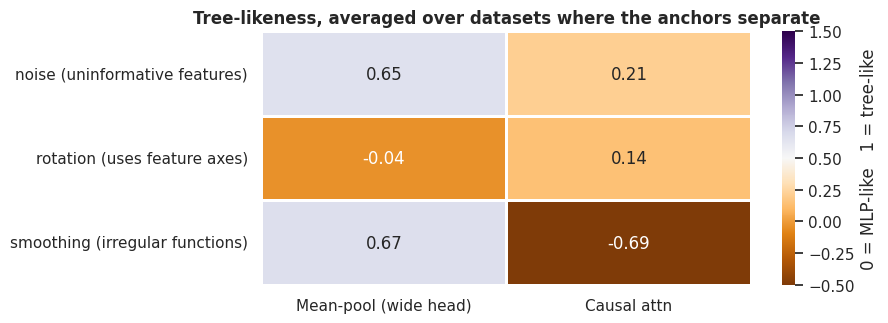

In [7]:
TESTS = {"noise (uninformative features)": "noise100", "rotation (uses feature axes)": "rotation",
         "smoothing (irregular functions)": "smooth_strong"}
mean_d = D.groupby(["dataset", "condition", "model"])["delta"].mean()
std_d = D.groupby(["dataset", "condition", "model"])["delta"].std()

rows = []
for ds in DATASETS_USED:
    for tname, cond in TESTS.items():
        dx, dm = mean_d[(ds, cond, "XGBoost")], mean_d[(ds, cond, "PlainMLP")]
        noise = np.sqrt(std_d[(ds, cond, "XGBoost")] ** 2 + std_d[(ds, cond, "PlainMLP")] ** 2)
        sep = abs(dx - dm) > max(noise, 0.002)
        row = {"dataset": DS_LABEL[ds], "test": tname, "Δ XGBoost": dx, "Δ PlainMLP": dm,
               "anchors separated": "yes" if sep else "no"}
        for m in OURS:
            row[f"score: {LABEL[m]}"] = (mean_d[(ds, cond, m)] - dm) / (dx - dm) if sep else np.nan
        rows.append(row)
SCORES = pd.DataFrame(rows).set_index(["test", "dataset"]).sort_index()
show(SCORES, {"Δ XGBoost": "{:+.4f}", "Δ PlainMLP": "{:+.4f}",
              **{f"score: {LABEL[m]}": "{:.2f}" for m in OURS}})

score_cols = [f"score: {LABEL[m]}" for m in OURS]
summary = SCORES.groupby(level="test")[score_cols].mean()
fig, ax = plt.subplots(figsize=(9, 3.4))
sns.heatmap(summary.clip(-0.5, 1.5), annot=summary.round(2), fmt="", cmap="PuOr", center=0.5, vmin=-0.5, vmax=1.5,
            cbar_kws={"label": "0 = MLP-like   1 = tree-like"}, ax=ax, linewidths=1, linecolor="white")
ax.set_xticklabels([c.replace("score: ", "") for c in summary.columns], rotation=0)
ax.set_ylabel(""); ax.set_title("Tree-likeness, averaged over datasets where the anchors separate",
                                fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Dose–response: does it get worse the harder you push?

A real effect should grow with the strength of the perturbation. These curves show accuracy at 0%, 50% and
100% extra noise columns, and at 0%, ~10% and ~25% of labels smoothed.

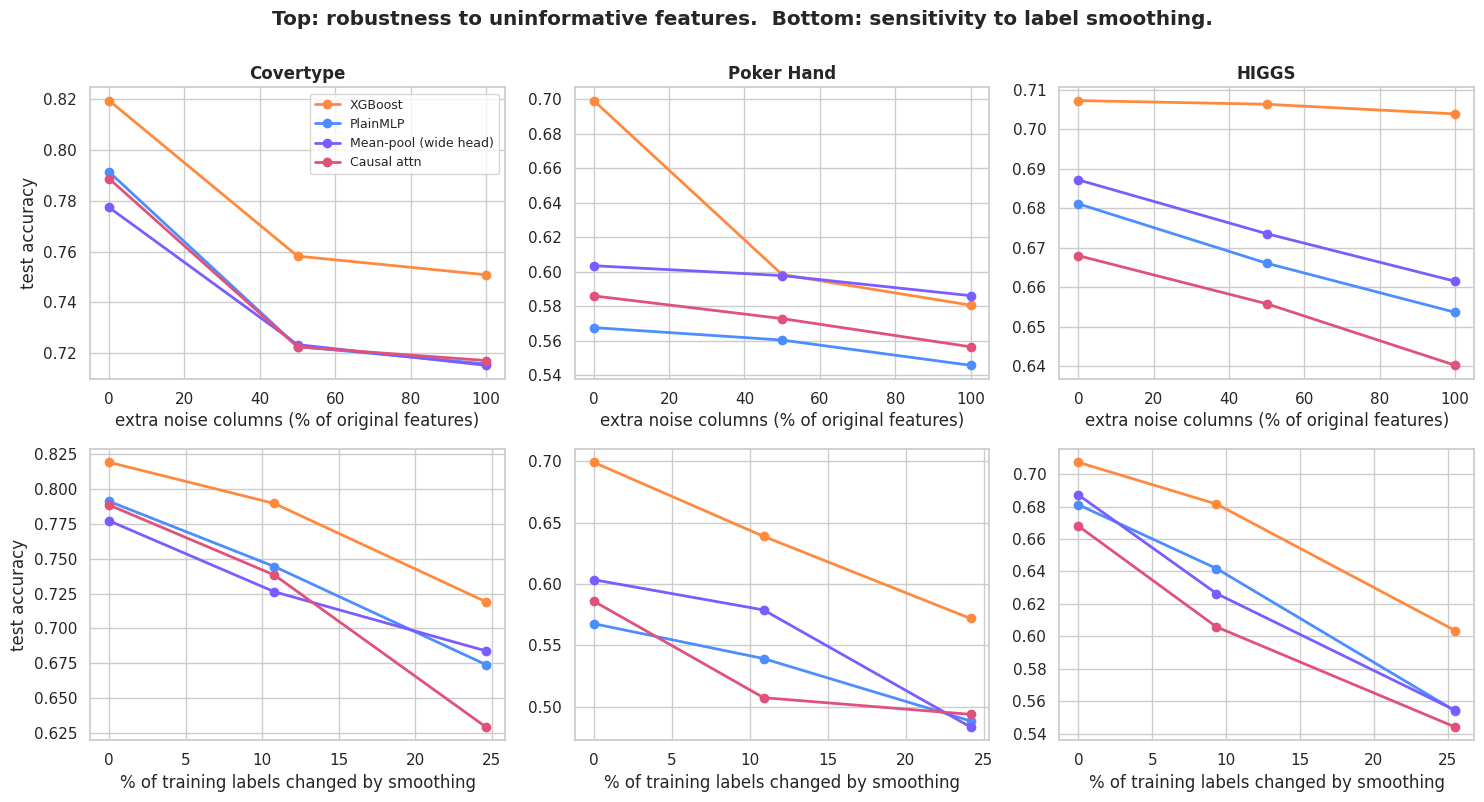

In [8]:
acc = R.groupby(["dataset", "condition", "model"])["acc"].mean()
fig, axes = plt.subplots(2, len(DATASETS_USED), figsize=(15, 8))
for j, ds in enumerate(DATASETS_USED):
    for m in MODELS:
        axes[0, j].plot([0, 50, 100], [acc[(ds, c, m)] for c in ("baseline", "noise50", "noise100")],
                        "-o", color=COLOR[m], label=LABEL[m], lw=2)
        xs = [0, SMOOTH_INFO[ds]["light"]["labels_changed"] * 100, SMOOTH_INFO[ds]["strong"]["labels_changed"] * 100]
        axes[1, j].plot(xs, [acc[(ds, c, m)] for c in ("baseline", "smooth_light", "smooth_strong")],
                        "-o", color=COLOR[m], label=LABEL[m], lw=2)
    axes[0, j].set_title(DS_LABEL[ds], fontweight="bold")
    axes[0, j].set_xlabel("extra noise columns (% of original features)")
    axes[1, j].set_xlabel("% of training labels changed by smoothing")
axes[0, 0].set_ylabel("test accuracy"); axes[1, 0].set_ylabel("test accuracy")
axes[0, 0].legend(fontsize=9)
plt.suptitle("Top: robustness to uninformative features.  Bottom: sensitivity to label smoothing.",
             fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

## 8. Where does the gap to XGBoost come from?

The paper's central argument: if a perturbation removes the thing trees are good at, the tree–NN gap
should **shrink**. Here is the gap between our best arm and XGBoost under each condition.

In [9]:
rows = []
for ds in DATASETS_USED:
    for cond in ["baseline"] + PERTURB:
        best_ours = max(acc[(ds, cond, m)] for m in OURS)
        rows.append({"dataset": DS_LABEL[ds], "condition": COND_LABEL[cond],
                     "XGBoost": acc[(ds, cond, "XGBoost")], "best of ours": best_ours,
                     "PlainMLP": acc[(ds, cond, "PlainMLP")],
                     "gap (ours − XGB)": best_ours - acc[(ds, cond, "XGBoost")]})
GAP = pd.DataFrame(rows).set_index(["dataset", "condition"])
show(GAP, {"XGBoost": "{:.4f}", "best of ours": "{:.4f}", "PlainMLP": "{:.4f}", "gap (ours − XGB)": "{:+.4f}"},
     style=lambda s: s.background_gradient(subset=["gap (ours − XGB)"], cmap="RdYlGn", vmin=-0.08, vmax=0.02))

XGBoost  best of ours  PlainMLP  gap (ours − XGB)
dataset    condition                                                        
Covertype  baseline         0.8194        0.7887    0.7913           -0.0307
           noise +50%       0.7582        0.7234    0.7227           -0.0348
           noise +100%      0.7509        0.7172    0.7158           -0.0337
           rotation         0.7969        0.7829    0.7894           -0.0141
           smoothing ~10%   0.7898        0.7384    0.7445           -0.0514
           smoothing ~25%   0.7192        0.6839    0.6740           -0.0353
Poker Hand baseline         0.6992        0.6035    0.5676           -0.0957
           noise +50%       0.5984        0.5978    0.5604           -0.0006
           noise +100%      0.5806        0.5861    0.5457            0.0055
           rotation         0.5229        0.6005    0.5692            0.0776
           smoothing ~10%   0.6388        0.5788    0.5392           -0.0600
           smoothing ~25%   0.5718        0.4936    0.4883           -0.0782
HIGGS      baseline         0.7073        0.6872    0.6812           -0.0201
           noise +50%       0.7064        0.6736    0.6661           -0.0328
           noise +100%      0.7039        0.6615    0.6537           -0.0424
           rotation         0.6147        0.6846    0.6826            0.0699
           smoothing ~10%   0.6816        0.6264    0.6418           -0.0552
           smoothing ~25%   0.6035        0.5543    0.5540           -0.0492

## 9. Findings

*(Computed from the runs above.)*

In [10]:
sep = "=" * 96
print(sep); print("FINDINGS — Grinsztajn diagnostics"); print(sep)

print("\n0. Baseline standing (test accuracy)")
for ds in DATASETS_USED:
    xb = acc[(ds, "baseline", "XGBoost")]; mp = acc[(ds, "baseline", "PlainMLP")]
    ours = {m: acc[(ds, "baseline", m)] for m in OURS}
    bm = max(ours, key=ours.get)
    print(f"   {DS_LABEL[ds]:10s} XGBoost {xb:.4f} | PlainMLP {mp:.4f} | best of ours {LABEL[bm]} {ours[bm]:.4f}"
          f"  (gap to XGB {ours[bm] - xb:+.4f}) | majority class {TASKS[ds]['baseline'].majority_acc:.4f}")

def verdict(score):
    if np.isnan(score): return "test could not separate the anchors"
    if score < 0.33: return "MLP-like  -> property MISSING"
    if score < 0.67: return "in between"
    return "tree-like -> property present"

for tname, cond in TESTS.items():
    print(f"\n{list(TESTS).index(tname) + 1}. {tname.upper()}")
    for ds in DATASETS_USED:
        r = SCORES.loc[(tname, DS_LABEL[ds])]
        parts = [f"XGB {r['Δ XGBoost']:+.4f}", f"MLP {r['Δ PlainMLP']:+.4f}"]
        parts += [f"{LABEL[m]} {mean_d[(ds, cond, m)]:+.4f}" for m in OURS]
        print(f"   {DS_LABEL[ds]:10s} Δacc: " + " | ".join(parts))
    for m in OURS:
        sc = summary.loc[tname, f"score: {LABEL[m]}"]
        print(f"   -> {LABEL[m]:22s} tree-likeness {sc:+.2f}   {verdict(sc)}")

print("\n4. Does attention route around noise? (Δacc under +100% noise, causal minus mean-pool)")
for ds in DATASETS_USED:
    dc, dmp = D[(D.dataset == ds) & (D.condition == "noise100") & (D.model == "causal")].set_index("seed")["delta"], \
              D[(D.dataset == ds) & (D.condition == "noise100") & (D.model == "meanpool_wide")].set_index("seed")["delta"]
    diff = (dc - dmp)
    print(f"   {DS_LABEL[ds]:10s} {diff.mean():+.4f} (per seed: {', '.join(f'{v:+.4f}' for v in diff.values)})"
          + ("   -> attention degrades LESS" if (diff > 0).all() else
             "   -> attention degrades MORE" if (diff < 0).all() else "   -> no consistent difference"))

print("\n5. Where the gap to XGBoost moves (best of ours − XGBoost)")
for ds in DATASETS_USED:
    g = GAP.loc[DS_LABEL[ds], "gap (ours − XGB)"]
    print(f"   {DS_LABEL[ds]:10s} baseline {g['baseline']:+.4f} | noise +100% {g['noise +100%']:+.4f} | "
          f"rotation {g['rotation']:+.4f} | smoothing ~25% {g['smoothing ~25%']:+.4f}")

print("\n6. Which Grinsztajn property should the next step target?")
avg = summary.mean(axis=1).sort_values()
for tname, sc in avg.items():
    print(f"   {tname:34s} mean tree-likeness of our arms {sc:+.2f}   {verdict(sc)}")
print(f"   -> weakest property: {avg.index[0]}")
print(sep)

FINDINGS — Grinsztajn diagnostics

0. Baseline standing (test accuracy)
   Covertype  XGBoost 0.8194 | PlainMLP 0.7913 | best of ours Causal attn 0.7887  (gap to XGB -0.0307) | majority class 0.4898
   Poker Hand XGBoost 0.6992 | PlainMLP 0.5676 | best of ours Mean-pool (wide head) 0.6035  (gap to XGB -0.0957) | majority class 0.5053
   HIGGS      XGBoost 0.7073 | PlainMLP 0.6812 | best of ours Mean-pool (wide head) 0.6872  (gap to XGB -0.0201) | majority class 0.5303

1. NOISE (UNINFORMATIVE FEATURES)
   Covertype  Δacc: XGB -0.0685 | MLP -0.0755 | Mean-pool (wide head) -0.0621 | Causal attn -0.0715
   Poker Hand Δacc: XGB -0.1186 | MLP -0.0219 | Mean-pool (wide head) -0.0174 | Causal attn -0.0295
   HIGGS      Δacc: XGB -0.0034 | MLP -0.0275 | Mean-pool (wide head) -0.0257 | Causal attn -0.0278
   -> Mean-pool (wide head)  tree-likeness +0.65   in between
   -> Causal attn            tree-likeness +0.21   MLP-like  -> property MISSING

2. ROTATION (USES FEATURE AXES)
   Covertype  Δa

## 10. From diagnosis to fixes

Each property maps to a concrete change that slots into the existing architecture without touching the rest:

| If this property is missing | Candidate fix | Where it goes |
|---|---|---|
| Robust to uninformative features | Learned per-feature **gates** (or group-L1) inside each expert, so it can switch off whole columns | `weak_learners.py` |
| Uses the feature axes | **Per-feature embeddings**: each raw feature gets its own small encoder before any mixing | new `embeddings.py`, in front of the experts |
| Learns irregular functions | **Piecewise-linear / periodic numerical embeddings** (Gorishniy et al., 2022), or **soft-tree experts** | `embeddings.py`, or a new expert type |

The tree-likeness scores above rank these by how badly each property is missing. Each fix is one isolated
change, evaluated with this same notebook: the diagnostic that exposed a gap is the one that should close it.